### Step 1: Dataset Loading & Exploratory Data Analysis

Libraries import


In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

Data Importing 

In [14]:
df = pd.read_csv("CC GENERAL.csv")

print(df.shape)
print(df.info())

(8950, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  


In [15]:
print(df.head(10))

  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   
5  C10006  1809.828751           1.000000    1333.28              0.00   
6  C10007   627.260806           1.000000    7091.01           6402.63   
7  C10008  1823.652743           1.000000     436.20              0.00   
8  C10009  1014.926473           1.000000     861.49            661.49   
9  C10010   152.225975           0.545455    1281.60           1281.60   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                   95.40      0.000000             0.166667   
1                    0.00   6442.945483             0.000

Finding missingvalues and filling missing values

In [16]:
df = df.drop("CUST_ID", axis=1)
print(df.isnull().sum())

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [21]:
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

print("\nMissing values after imputation:")
print("CREDIT_LIMIT : ",df["CREDIT_LIMIT"].isnull().sum())
print("MINIMUM_PAYMENTS : ",df["MINIMUM_PAYMENTS"].isnull().sum())


Missing values after imputation:
CREDIT_LIMIT :  0
MINIMUM_PAYMENTS :  0


Checking Duplicate Rows

In [23]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


Univariate Analysis


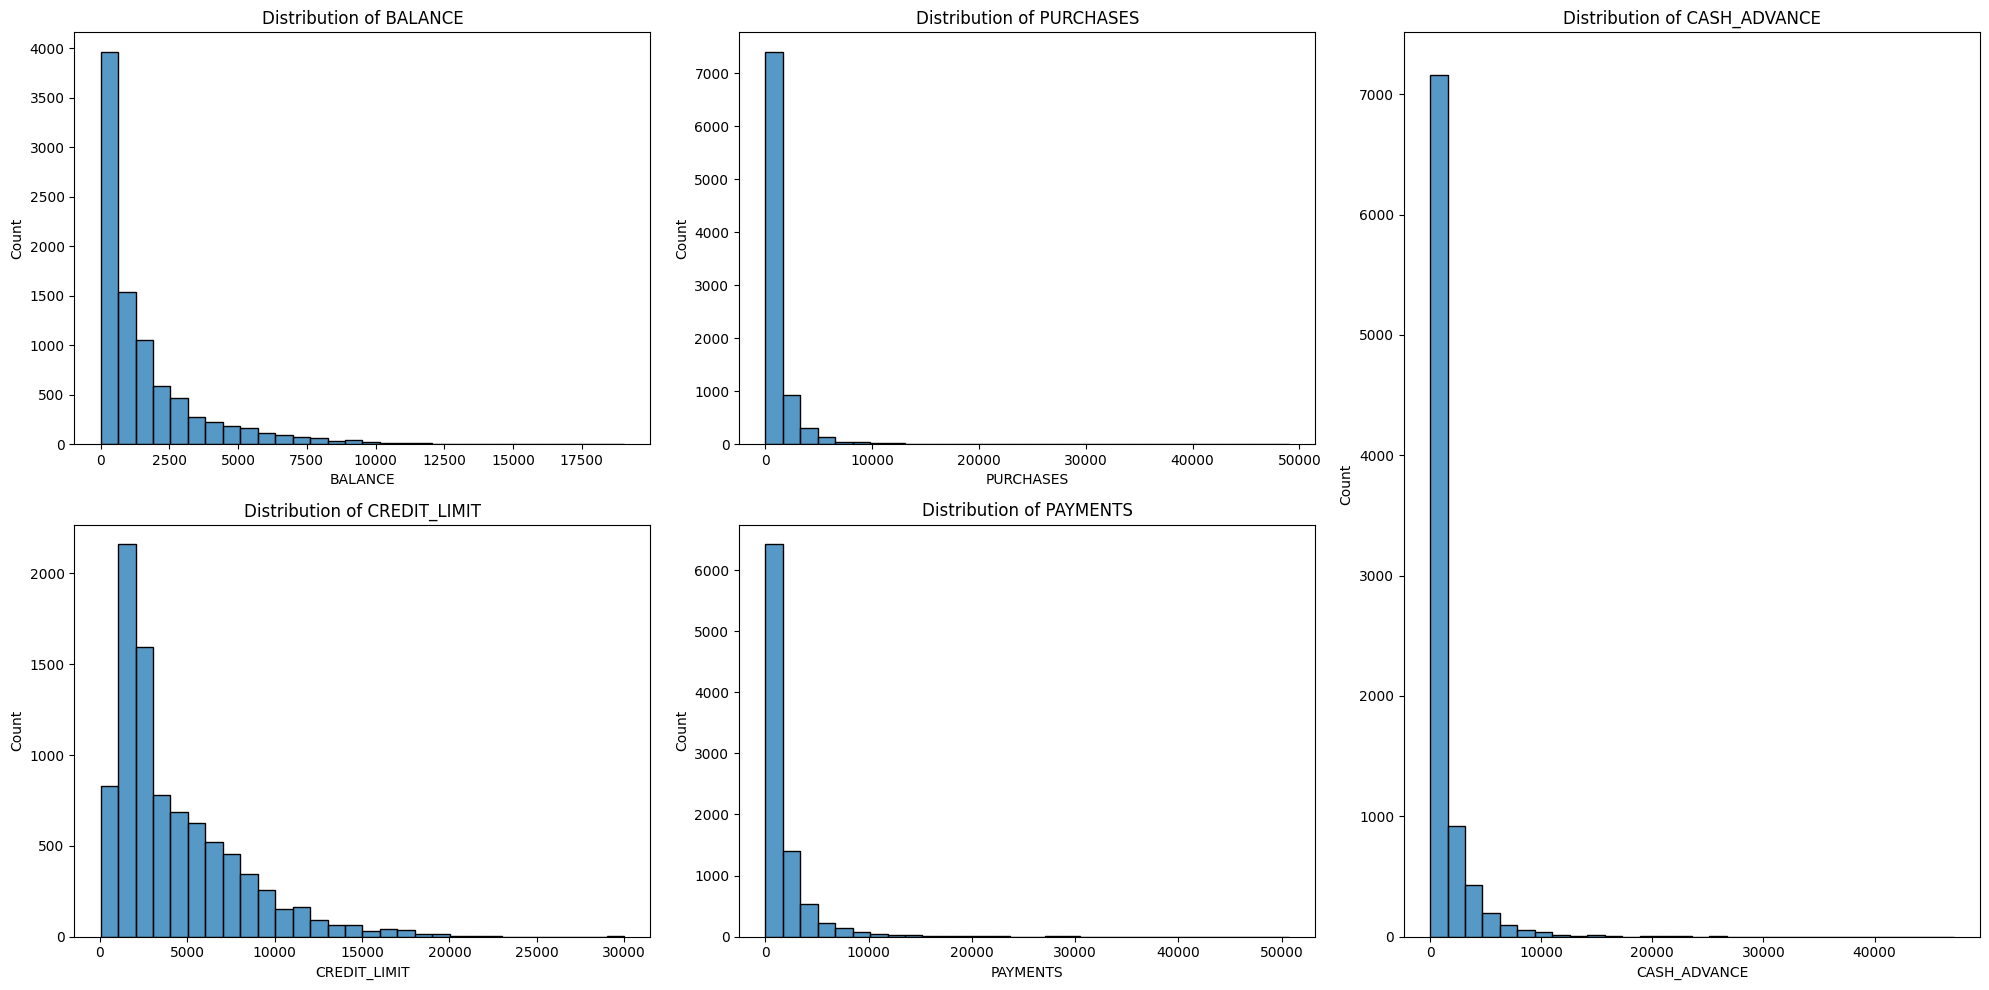

In [74]:
plt.figure(figsize=(20,10))

plt.subplot(2, 3, 1)
sns.histplot(df["BALANCE"], bins=30)
plt.title(f"Distribution of {"BALANCE"}")
plt.xlabel("BALANCE")
plt.ylabel("Count")

plt.subplot(2, 3, 2)
sns.histplot(df["PURCHASES"], bins=30)
plt.title(f"Distribution of {"PURCHASES"}")
plt.xlabel("PURCHASES")
plt.ylabel("Count")

plt.subplot(1, 3, 3)
sns.histplot(df["CASH_ADVANCE"], bins=30)
plt.title(f"Distribution of {"CASH_ADVANCE"}")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("Count")

plt.subplot(2, 3, 4)
sns.histplot(df["CREDIT_LIMIT"], bins=30)
plt.title(f"Distribution of {"CREDIT_LIMIT"}")
plt.xlabel("CREDIT_LIMIT")
plt.ylabel("Count")

plt.subplot(2, 3, 5)
sns.histplot(df["PAYMENTS"], bins=30)
plt.title(f"Distribution of {"PAYMENTS"}")
plt.xlabel("PAYMENTS")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


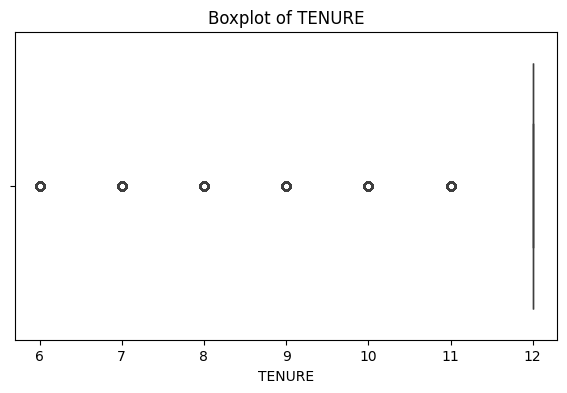

In [43]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df["TENURE"])
plt.title("Boxplot of TENURE")
plt.xlabel("TENURE")

plt.show()

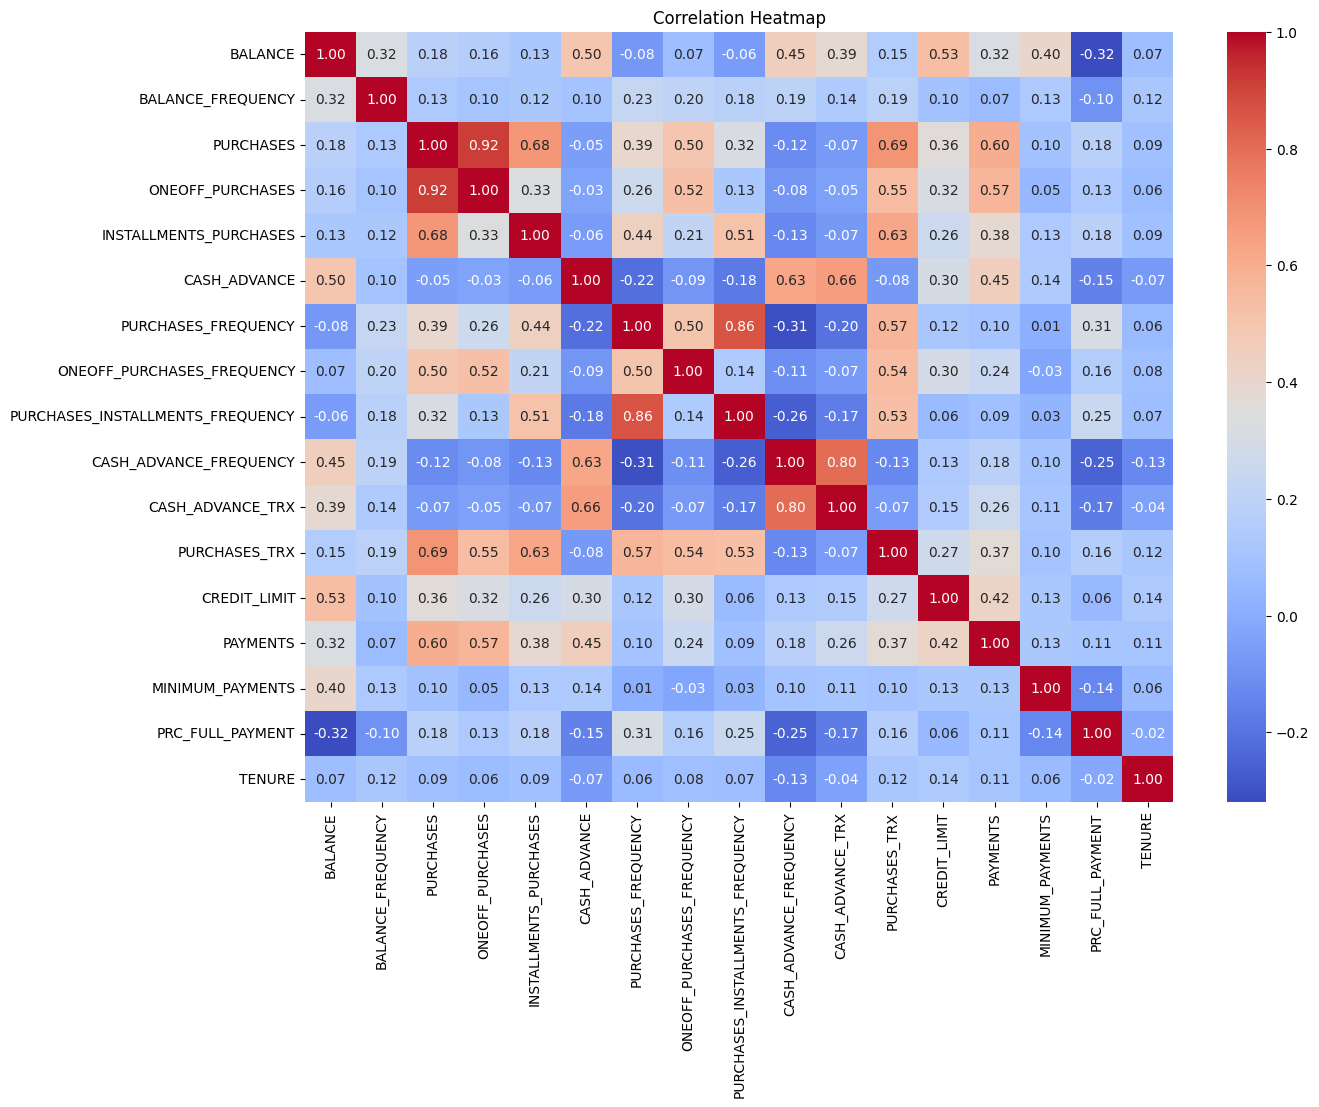

In [45]:
plt.figure(figsize=(14, 10))
sns.heatmap( df.corr(), annot=True, fmt=".2f", cmap="coolwarm" )
plt.title("Correlation Heatmap")
plt.show()

Customer-Level Analysis


In [46]:
df["Purchase_Utilisation"] = df["PURCHASES"] / df["CREDIT_LIMIT"]

print(df[["PURCHASES", "CREDIT_LIMIT", "Purchase_Utilisation"]].head())

   PURCHASES  CREDIT_LIMIT  Purchase_Utilisation
0      95.40        1000.0              0.095400
1       0.00        7000.0              0.000000
2     773.17        7500.0              0.103089
3    1499.00        7500.0              0.199867
4      16.00        1200.0              0.013333


In [48]:
top_cash_advance = df.nlargest(10, "CASH_ADVANCE")
print(top_cash_advance[["CASH_ADVANCE", "PURCHASES"]])

      CASH_ADVANCE  PURCHASES
2159   47137.21176     431.93
1059   29282.10915    3719.00
71     27296.48576    4523.27
7254   26268.69989    1750.66
7645   26194.04954       0.00
2454   23130.82106       0.00
883    22665.77850       0.00
6371   21943.84942       0.00
3806   20712.67008    4995.80
6455   20277.33112    1490.75


In [51]:
zero_purchase = (df["PURCHASES"] == 0).sum()
percentage = (zero_purchase / len(df)) * 100
print("Customers with zero purchases:", zero_purchase)
print("Percentage:", percentage, "%")

Customers with zero purchases: 2044
Percentage: 22.837988826815643 %


### Step 2: Feature Engineering & Preprocessing

Engineer Behavioural Features

In [68]:
df["Monthly_Avg_Purchase"] = df["PURCHASES"] / df["TENURE"]
df["Monthly_Avg_Cash_Advance"] = df["CASH_ADVANCE"] / df["TENURE"]
df["Limit_Usage"] = df["BALANCE"] / df["CREDIT_LIMIT"]
df["Payment_to_Minpayment_Ratio"] = (df["PAYMENTS"] / (df["MINIMUM_PAYMENTS"] + 1))

Handle Outliers

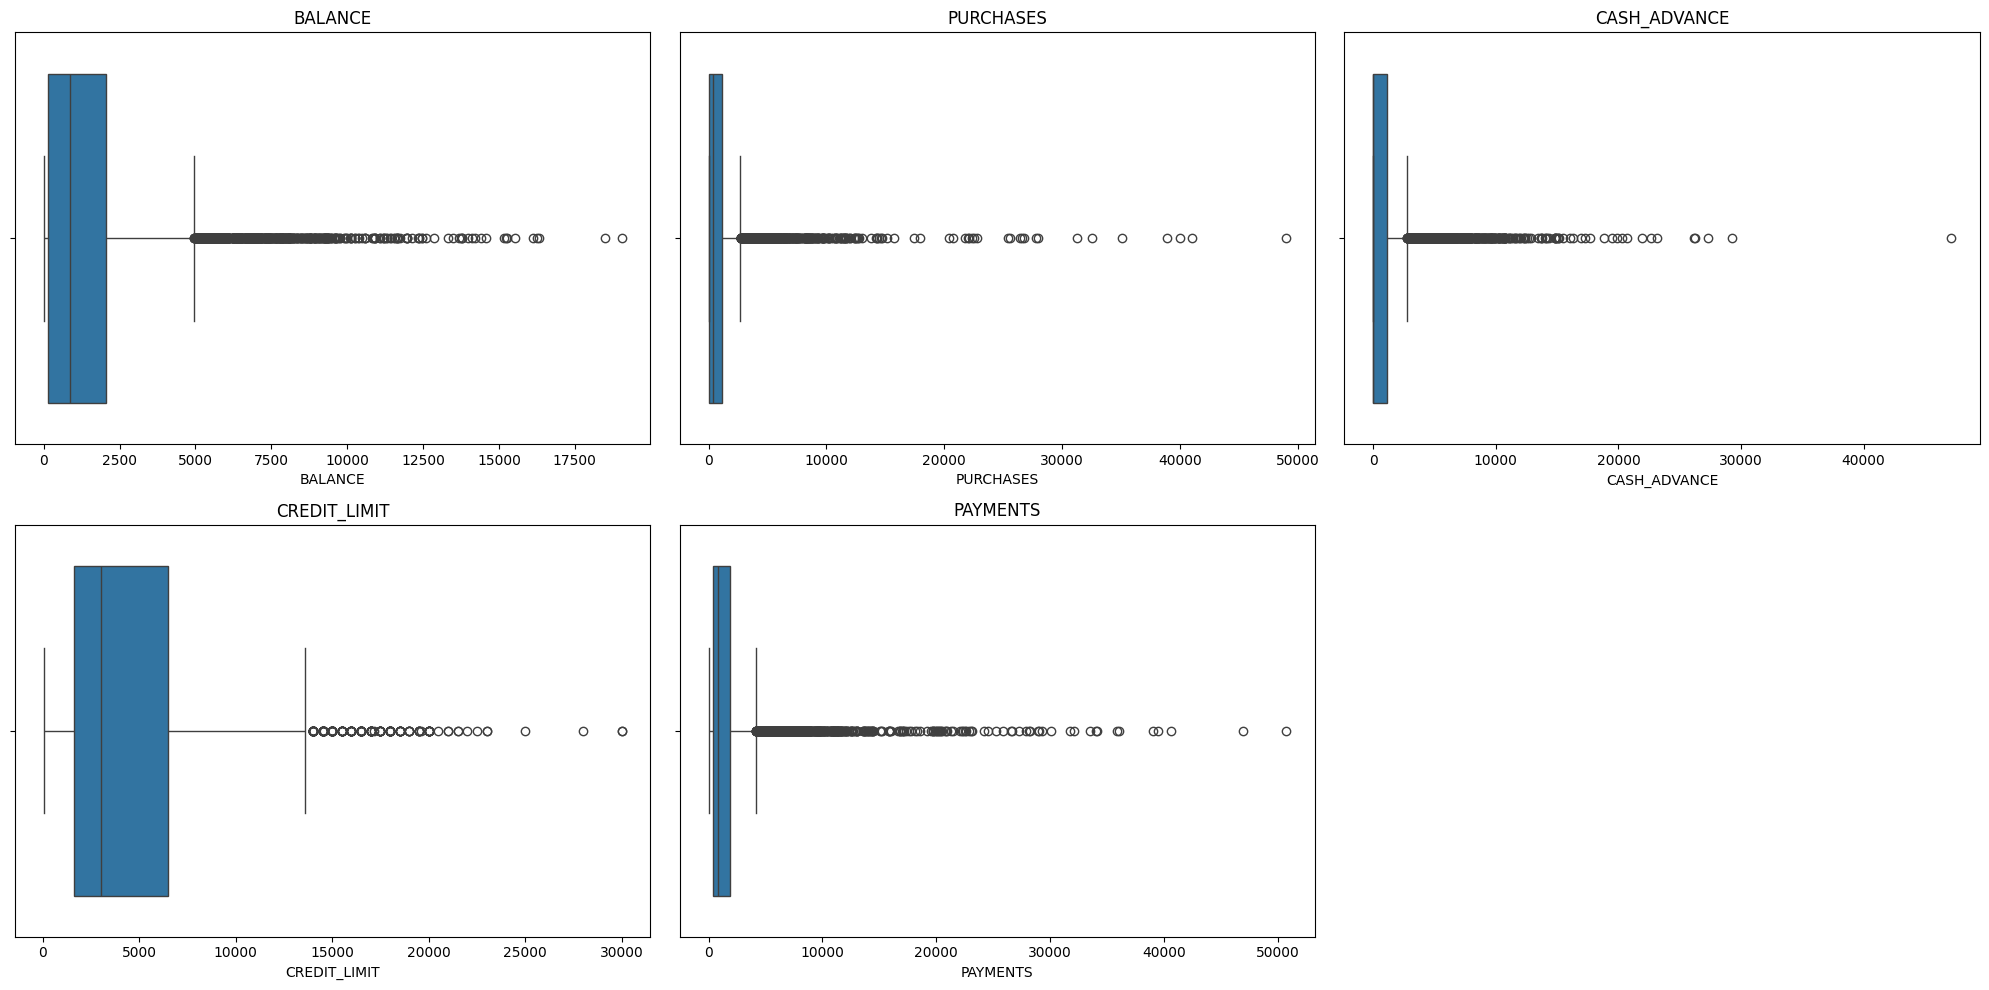

In [73]:
plt.figure(figsize=(20,10))

plt.subplot(2, 3, 1)
sns.boxplot(x=df["BALANCE"])
plt.title("BALANCE")

plt.subplot(2, 3, 2)
sns.boxplot(x=df["PURCHASES"])
plt.title("PURCHASES")

plt.subplot(2, 3, 3)
sns.boxplot(x=df["CASH_ADVANCE"])
plt.title("CASH_ADVANCE")

plt.subplot(2, 3, 4)
sns.boxplot(x=df["CREDIT_LIMIT"])
plt.title("CREDIT_LIMIT")

plt.subplot(2, 3, 5)
sns.boxplot(x=df["PAYMENTS"])
plt.title("PAYMENTS")

plt.tight_layout()
plt.show()


In [78]:
columns = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    upper_limit = Q3 + 3 * IQR
    
    df[col] = df[col].clip(upper=upper_limit)

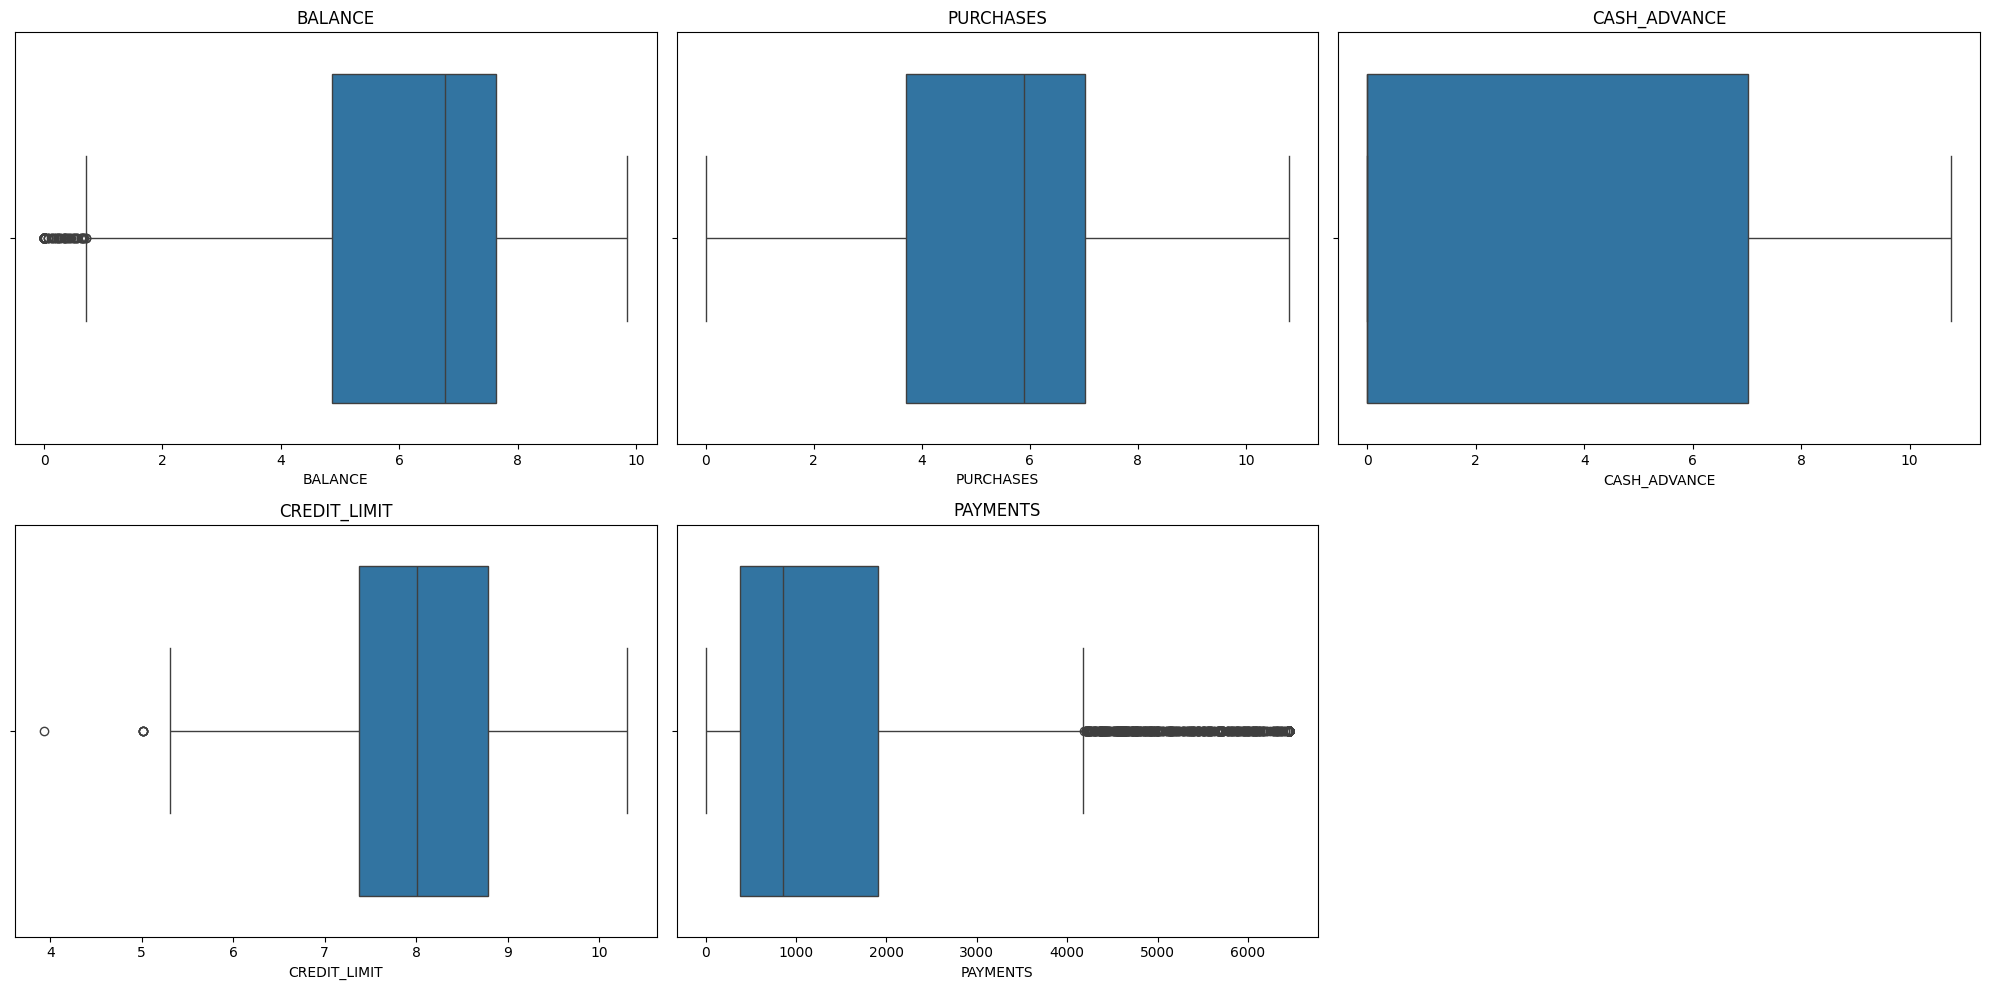

In [79]:
plt.figure(figsize=(20,10))

plt.subplot(2, 3, 1)
sns.boxplot(x=df["BALANCE"])
plt.title("BALANCE")

plt.subplot(2, 3, 2)
sns.boxplot(x=df["PURCHASES"])
plt.title("PURCHASES")

plt.subplot(2, 3, 3)
sns.boxplot(x=df["CASH_ADVANCE"])
plt.title("CASH_ADVANCE")

plt.subplot(2, 3, 4)
sns.boxplot(x=df["CREDIT_LIMIT"])
plt.title("CREDIT_LIMIT")

plt.subplot(2, 3, 5)
sns.boxplot(x=df["PAYMENTS"])
plt.title("PAYMENTS")

plt.tight_layout()
plt.show()


Transform Skewed Features


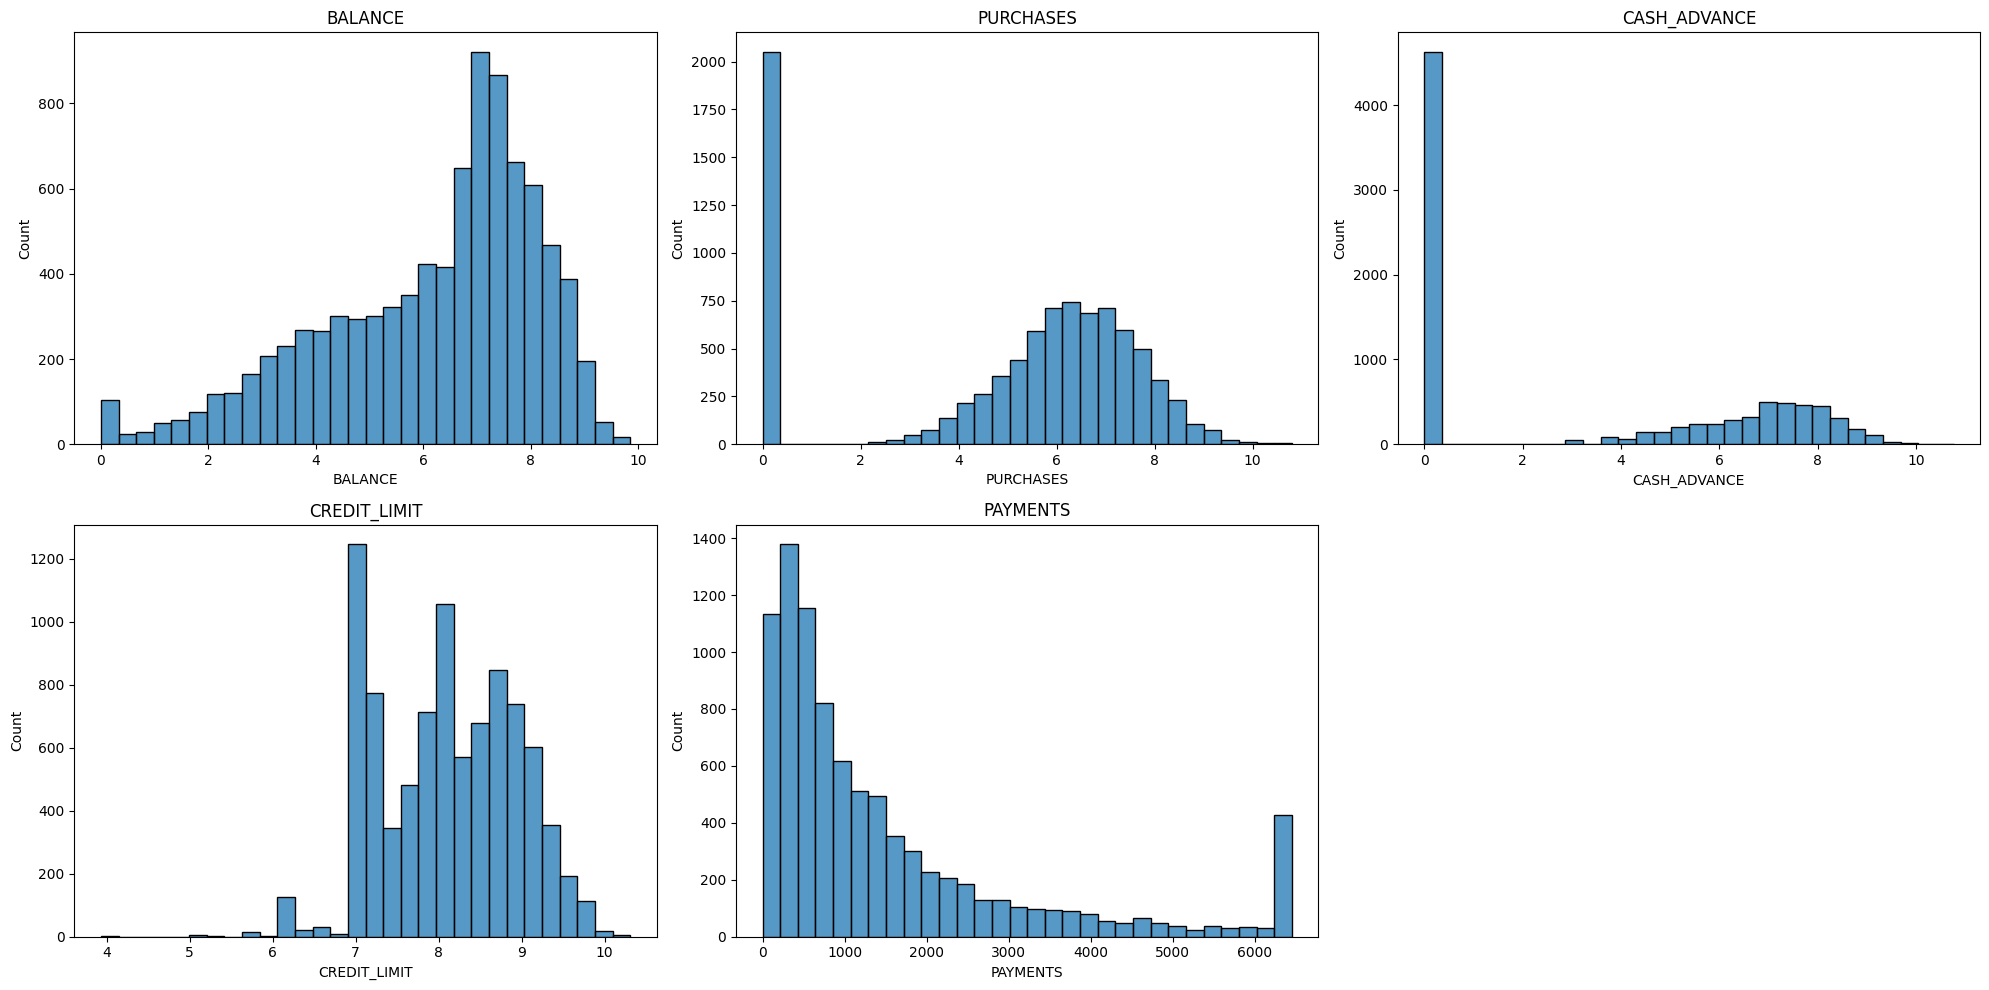

In [80]:
plt.figure(figsize=(20,10))

plt.subplot(2, 3, 1)
sns.histplot(df["BALANCE"], bins=30)
plt.title("BALANCE")

plt.subplot(2, 3, 2)
sns.histplot(df["PURCHASES"], bins=30)
plt.title("PURCHASES")

plt.subplot(2, 3, 3)
sns.histplot(df["CASH_ADVANCE"], bins=30)
plt.title("CASH_ADVANCE")

plt.subplot(2, 3, 4)
sns.histplot(df["CREDIT_LIMIT"], bins=30)
plt.title("CREDIT_LIMIT")

plt.subplot(2, 3, 5)
sns.histplot(df["PAYMENTS"], bins=30)
plt.title("PAYMENTS")

plt.tight_layout()
plt.show()


In [81]:
columns = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT"]

for col in columns:
    df[col] = np.log1p(df[col])

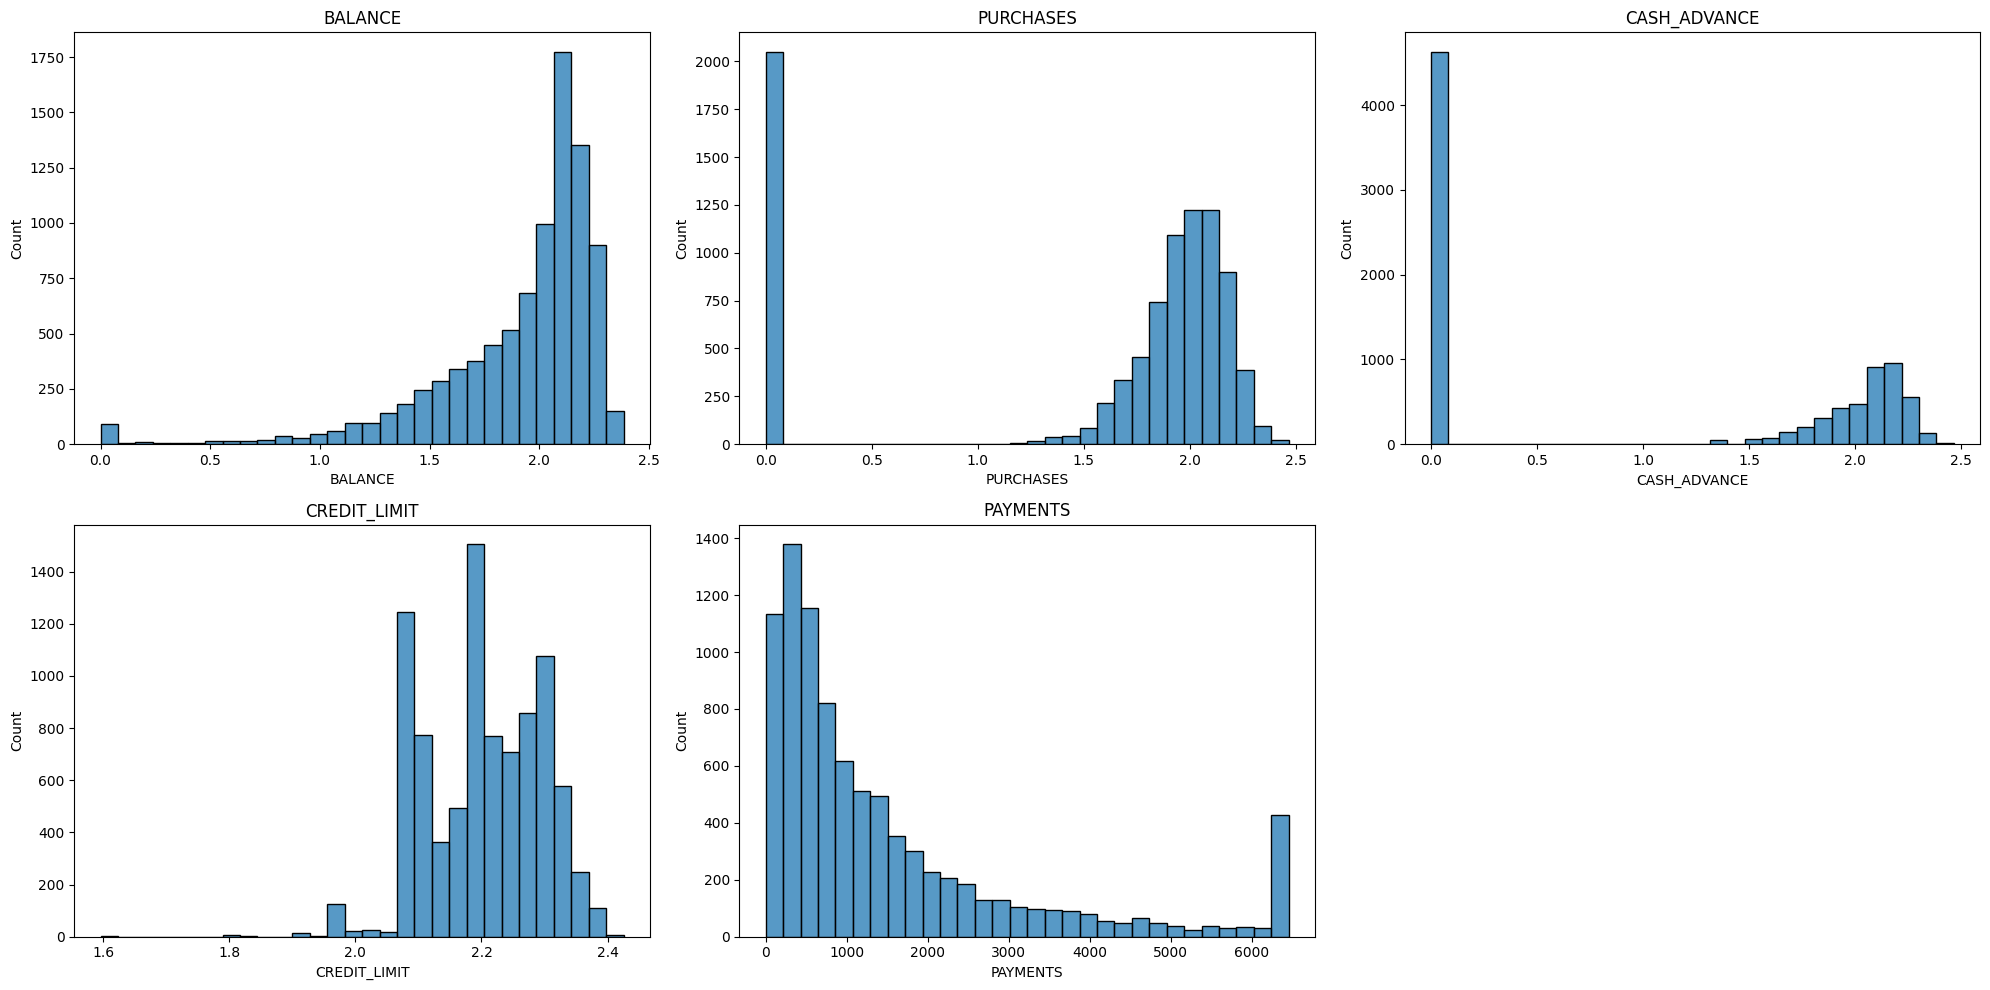

In [82]:
plt.figure(figsize=(20,10))

plt.subplot(2, 3, 1)
sns.histplot(df["BALANCE"], bins=30)
plt.title("BALANCE")

plt.subplot(2, 3, 2)
sns.histplot(df["PURCHASES"], bins=30)
plt.title("PURCHASES")

plt.subplot(2, 3, 3)
sns.histplot(df["CASH_ADVANCE"], bins=30)
plt.title("CASH_ADVANCE")

plt.subplot(2, 3, 4)
sns.histplot(df["CREDIT_LIMIT"], bins=30)
plt.title("CREDIT_LIMIT")

plt.subplot(2, 3, 5)
sns.histplot(df["PAYMENTS"], bins=30)
plt.title("PAYMENTS")

plt.tight_layout()
plt.show()


Scale the Features

In [86]:
scaler = StandardScaler()
cc_scaled = scaler.fit_transform(df)

print("Mean of scaled features:")
print(cc_scaled.mean(axis=0))

print("\nStandard deviation of scaled features:")
print(cc_scaled.std(axis=0))

Mean of scaled features:
[ 3.81073199e-17  1.58780500e-16 -8.01841523e-17 -6.03365899e-17
  3.17560999e-17 -3.96951249e-17  9.32835435e-17  1.90536600e-17
  5.71609799e-17 -1.59574402e-16 -1.74658550e-17 -1.90536600e-17
 -2.81994167e-15  1.27024400e-16  1.27024400e-17 -9.52682998e-18
  2.92156119e-16 -4.76341499e-17 -3.17560999e-17 -7.93902498e-19
 -1.01619520e-16 -4.36646374e-18]

Standard deviation of scaled features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: K-Means Clustering

Elbow Method — Find Optimal k

In [101]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    
    kmeans.fit(cc_scaled)
    inertia.append(kmeans.inertia_)

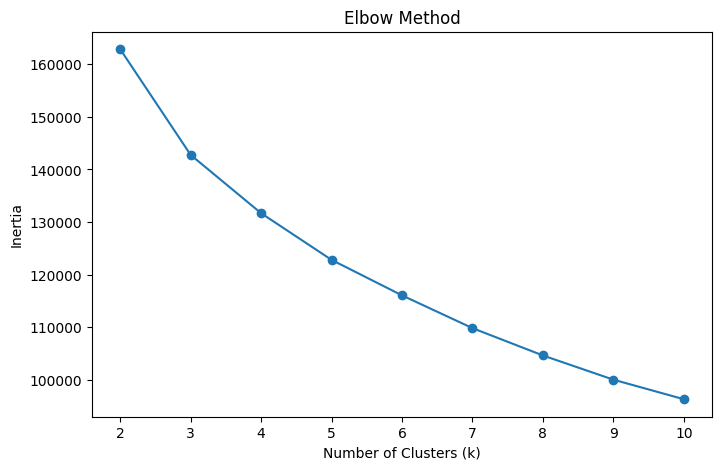

In [93]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [102]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    
    labels = kmeans.fit_predict(cc_scaled)
    score = silhouette_score(cc_scaled, labels)
    silhouette_scores.append(score)

    print("k =", k, "Silhouette Score =", score)

k = 2 Silhouette Score = 0.20319350189412932
k = 3 Silhouette Score = 0.20299043433452596
k = 4 Silhouette Score = 0.19051956359197594
k = 5 Silhouette Score = 0.1853665442151002
k = 6 Silhouette Score = 0.1746794603406126
k = 7 Silhouette Score = 0.16424491354895765
k = 8 Silhouette Score = 0.16592630361648783
k = 9 Silhouette Score = 0.17031094984487868
k = 10 Silhouette Score = 0.17506071459668057


Based on your actual results, k = 2 has the highest silhouette score, while k = 3 is nearly identical. We can use the elbow plot alongside this when documenting the choice.

Train Final K-Means Model

In [103]:
k_optimal = 2

kmeans_final = KMeans(
    n_clusters=k_optimal,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

kmeans_labels = kmeans_final.fit_predict(cc_scaled)

df["KMeans_Cluster"] = kmeans_labels

print(df["KMeans_Cluster"].value_counts())

KMeans_Cluster
0    5431
1    3519
Name: count, dtype: int64


Visualise K-Means Clusters

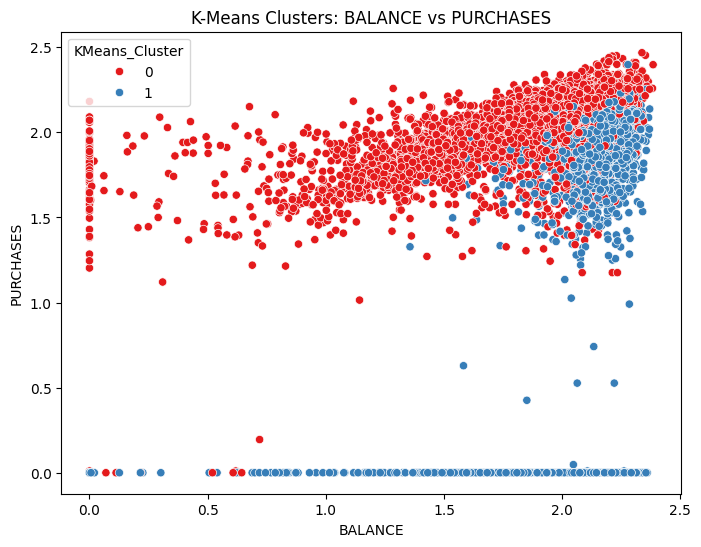

In [104]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df["BALANCE"],
    y=df["PURCHASES"],
    hue=df["KMeans_Cluster"],
    palette="Set1"
)

plt.title("K-Means Clusters: BALANCE vs PURCHASES")
plt.xlabel("BALANCE")
plt.ylabel("PURCHASES")
plt.show()

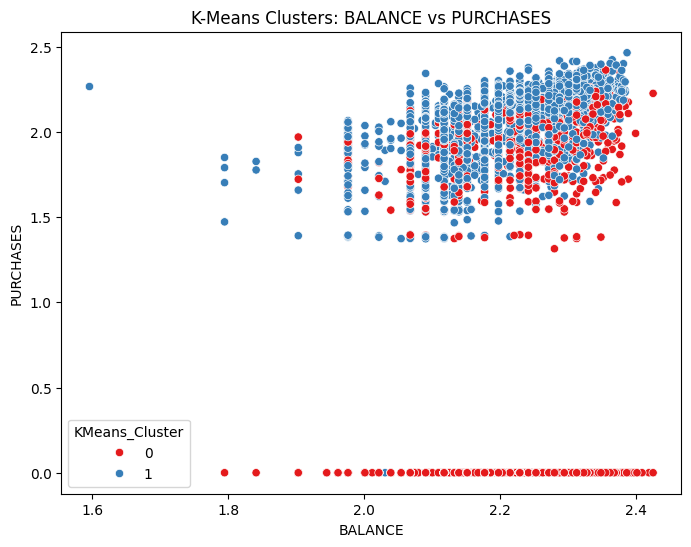

In [105]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df["CREDIT_LIMIT"],
    y=df["CASH_ADVANCE"],
    hue=df["KMeans_Cluster"],
    palette="Set1"
)

plt.title("K-Means Clusters: BALANCE vs PURCHASES")
plt.xlabel("BALANCE")
plt.ylabel("PURCHASES")
plt.show()

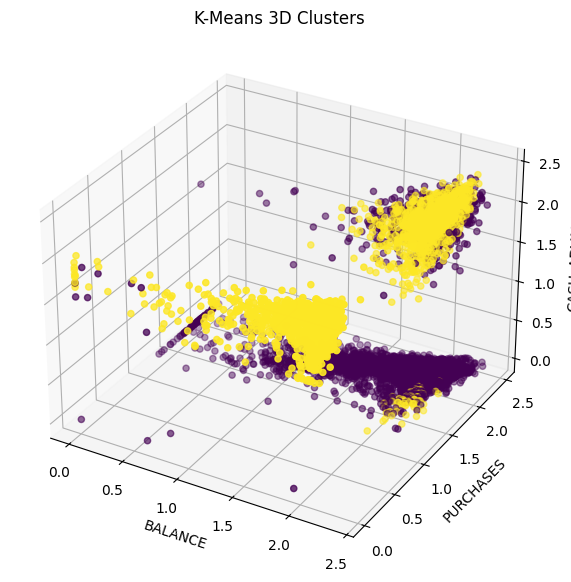

In [109]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["BALANCE"],
    df["PURCHASES"],
    df["CASH_ADVANCE"],
    c=df["KMeans_Cluster"],
)

ax.set_xlabel("BALANCE")
ax.set_ylabel("PURCHASES")
ax.set_zlabel("CASH_ADVANCE")
ax.set_title("K-Means 3D Clusters")

plt.show()

Profile the K-Means Clusters


In [110]:
profile = df.groupby("KMeans_Cluster")[
    ["BALANCE", "PURCHASES", "CASH_ADVANCE",
     "CREDIT_LIMIT", "PAYMENTS", "TENURE"]
].mean()

profile = profile.sort_values("CREDIT_LIMIT", ascending=False)

print(profile)

                 BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT     PAYMENTS  \
KMeans_Cluster                                                                 
0               1.796150   2.000159      0.316945      2.204643  1429.364864   
1               2.087698   0.790401      2.024006      2.201934  1593.891923   

                   TENURE  
KMeans_Cluster             
0               11.641871  
1               11.325092  


### Step 4: Agglomerative Hierarchical Clustering


Dendrogram Analysis

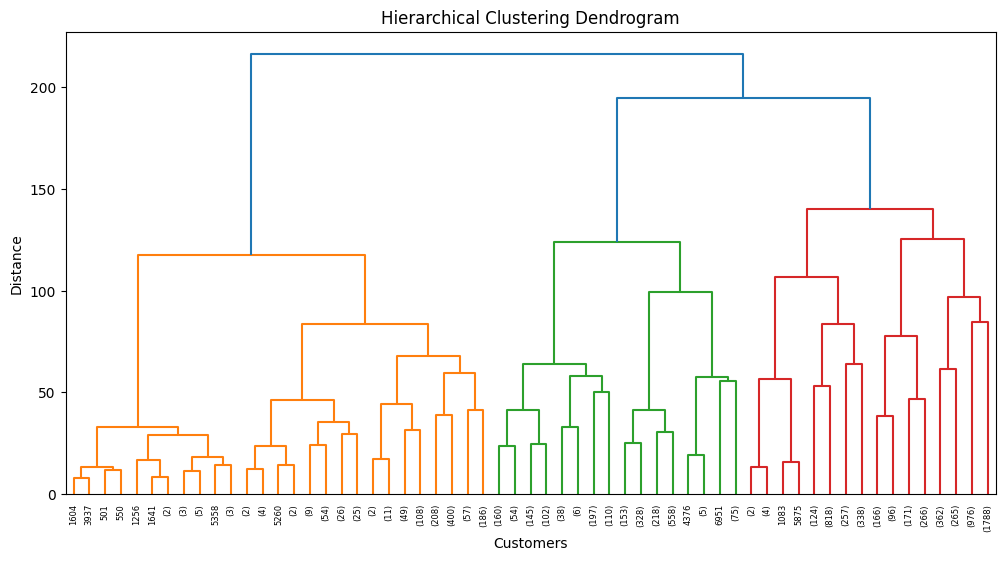

In [112]:
linked = linkage(cc_scaled, method="ward")

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

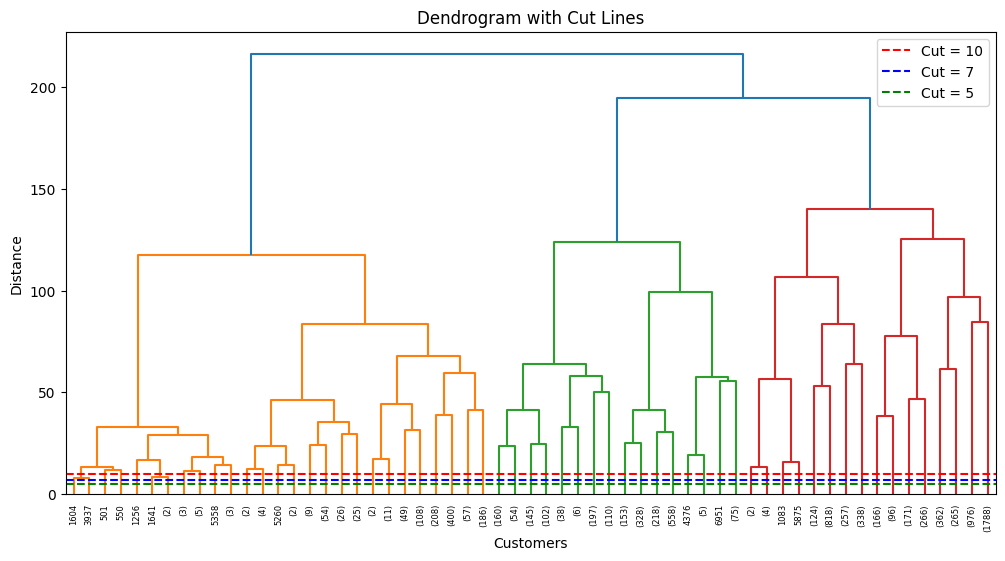

In [113]:
plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.axhline(y=10, color="red", linestyle="--", label="Cut = 10")
plt.axhline(y=7, color="blue", linestyle="--", label="Cut = 7")
plt.axhline(y=5, color="green", linestyle="--", label="Cut = 5")

plt.title("Dendrogram with Cut Lines")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.legend()

plt.show()

Train Agglomerative Model

In [118]:
n_chosen = 4
agg_ward = AgglomerativeClustering( n_clusters=n_chosen, linkage="ward")
agg_labels = agg_ward.fit_predict(cc_scaled)
df["Agg_Cluster"] = agg_labels

print(df["Agg_Cluster"].value_counts())

Agg_Cluster
0    4090
2    2151
3    1545
1    1164
Name: count, dtype: int64


In [120]:
agg_complete = AgglomerativeClustering(
    n_clusters=4,
    linkage="complete"
)

agg_average = AgglomerativeClustering(
    n_clusters=4,
    linkage="average"
)

complete_labels = agg_complete.fit_predict(cc_scaled)
average_labels = agg_average.fit_predict(cc_scaled)

score_ward = silhouette_score(cc_scaled, agg_labels)
score_complete = silhouette_score(cc_scaled, complete_labels)
score_average = silhouette_score(cc_scaled, average_labels)

print("Ward Silhouette:", score_ward)
print("Complete Silhouette:", score_complete)
print("Average Silhouette:", score_average)

Ward Silhouette: 0.12753988709068523
Complete Silhouette: 0.7935526560939099
Average Silhouette: 0.8266618978673272


In [121]:
agg_final = AgglomerativeClustering(
    n_clusters=4,
    linkage="average"
)

agg_labels = agg_final.fit_predict(cc_scaled)

df["Agg_Cluster"] = agg_labels

print(df["Agg_Cluster"].value_counts())

Agg_Cluster
0    8946
1       2
3       1
2       1
Name: count, dtype: int64


Visualise & Profile Hierarchical Clusters

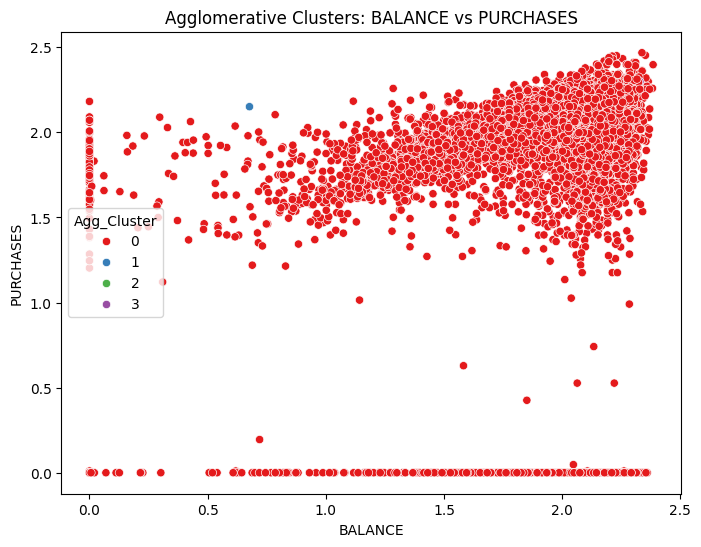

In [122]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df["BALANCE"],
    y=df["PURCHASES"],
    hue=df["Agg_Cluster"],
    palette="Set1"
)

plt.title("Agglomerative Clusters: BALANCE vs PURCHASES")
plt.xlabel("BALANCE")
plt.ylabel("PURCHASES")
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df["BALANCE"],
    y=df["PURCHASES"],
    hue=df["Agg_Cluster"],
    palette="Set1"
)

plt.title("Agglomerative Clusters: BALANCE vs PURCHASES")
plt.xlabel("BALANCE")
plt.ylabel("PURCHASES")
plt.show()

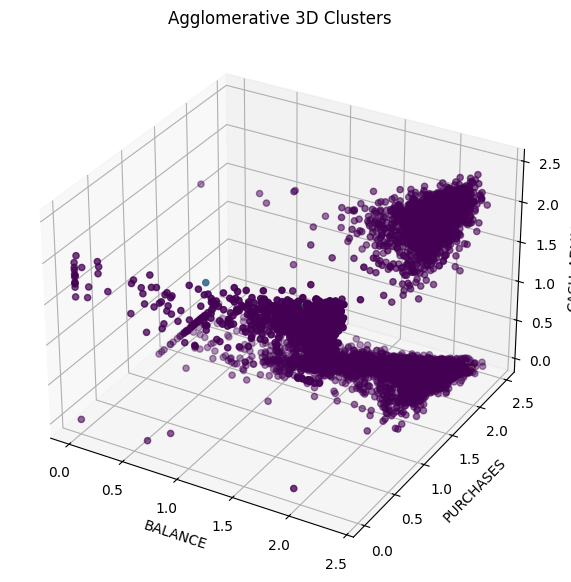

In [127]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df["BALANCE"],
    df["PURCHASES"],
    df["CASH_ADVANCE"],
    c=df["Agg_Cluster"],

)

ax.set_xlabel("BALANCE")
ax.set_ylabel("PURCHASES")
ax.set_zlabel("CASH_ADVANCE")
ax.set_title("Agglomerative 3D Clusters")

plt.show()

In [129]:
kmeans_silhouette = silhouette_score(cc_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(cc_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(cc_scaled, kmeans_labels)

agg_silhouette = silhouette_score(cc_scaled, agg_labels)
agg_db = davies_bouldin_score(cc_scaled, agg_labels)
agg_ch = calinski_harabasz_score(cc_scaled, agg_labels)

print("K-Means")
print("Silhouette Score:", kmeans_silhouette)
print("Davies-Bouldin Index:", kmeans_db)
print("Calinski-Harabasz Index:", kmeans_ch)

print("\nAgglomerative")
print("Silhouette Score:", agg_silhouette)
print("Davies-Bouldin Index:", agg_db)
print("Calinski-Harabasz Index:", agg_ch)

K-Means
Silhouette Score: 0.2031519164242244
Davies-Bouldin Index: 1.8049115308958097
Calinski-Harabasz Index: 1870.7664845990325

Agglomerative
Silhouette Score: 0.8266618978673272
Davies-Bouldin Index: 0.17611219817020396
Calinski-Harabasz Index: 127.38457817053025


In [130]:
metrics_comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "Agglomerative"],
    "Silhouette": [kmeans_silhouette, agg_silhouette],
    "Davies_Bouldin": [kmeans_db, agg_db],
    "Calinski_Harabasz": [kmeans_ch, agg_ch]
})

print(metrics_comparison)

       Algorithm  Silhouette  Davies_Bouldin  Calinski_Harabasz
0        K-Means    0.203152        1.804912        1870.766485
1  Agglomerative    0.826662        0.176112         127.384578


In [133]:
random_states = [0, 7, 21, 42, 99]

s_scores = []

for state in random_states:
    kmeans = KMeans(
        n_clusters=k_optimal,
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=state
    )

    labels = kmeans.fit_predict(cc_scaled)
    score = silhouette_score(cc_scaled, labels)

    s_scores.append(score)

    print(f"Random State {state}: {score:.4f}")

print("\nMean Silhouette:", np.mean(s_scores))
print("Standard Deviation:", np.std(s_scores))

Random State 0: 0.2032
Random State 7: 0.2032
Random State 21: 0.2032
Random State 42: 0.2032
Random State 99: 0.2032

Mean Silhouette: 0.20318168377213777
Standard Deviation: 1.848615709377403e-05
